# Actions and policies demo

Shows how the shift **actions** (`left` / `right` / do-nothing) and a **policy**
affect the tasks. An action moves the vector one cell (cutting off one end and
filling the other with a fresh task-appropriate sample); `RandomShiftPolicy`
takes a shift with probability `action_probability` each step (left/right equally
likely) and otherwise does nothing.

Recall the action taken at step t modifies the observation at step t+1.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from tasks import (BinaryNoiseTask, DriftTask, GaussianProcessTask,
                   RandomShiftPolicy, rollout)
from tasks.actions import NONE, LEFT, RIGHT, ACTION_NAMES

## A helper to plot a rollout

Observations as a heatmap, with a strip above marking the action taken at each
step (blue = left, red = right, blank = do-nothing).


In [2]:
_ACTION_COLORS = {NONE: (1, 1, 1), LEFT: (0.20, 0.40, 0.85), RIGHT: (0.85, 0.25, 0.20)}

def plot_rollout(observations, actions, title, vmin=0, vmax=1):
    T = observations.shape[0]
    fig, (ax_a, ax_o) = plt.subplots(
        2, 1, figsize=(10, 4.5), sharex=True,
        gridspec_kw={'height_ratios': [1, 8], 'hspace': 0.05})

    strip = np.array([_ACTION_COLORS[int(a)] for a in actions])[None, :, :]  # (1, T, 3)
    ax_a.imshow(strip, aspect='auto', interpolation='nearest', extent=[-0.5, T - 0.5, 0, 1])
    ax_a.set_yticks([])
    ax_a.set_title(title)

    im = ax_o.imshow(observations.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
                     interpolation='nearest')
    ax_o.set_xlabel('timestep')
    ax_o.set_ylabel('vector element')
    fig.colorbar(im, ax=[ax_a, ax_o])

    # legend
    from matplotlib.patches import Patch
    ax_a.legend(handles=[Patch(color=_ACTION_COLORS[LEFT], label='left'),
                         Patch(color=_ACTION_COLORS[RIGHT], label='right')],
                loc='upper right', ncol=2, fontsize=8, framealpha=0.9,
                bbox_to_anchor=(1.0, 3.0))
    plt.show()

    counts = {ACTION_NAMES[a]: int((actions == a).sum()) for a in (NONE, LEFT, RIGHT)}
    print('action counts:', counts)

## 1. Drift + actions

Drift already slides the vector right every step. A `left` action cancels one
step of drift, a `right` action compounds it -- and because drift carries its
state forward, these effects **persist**. Watch the diagonal bands bend where
runs of the same action occur.


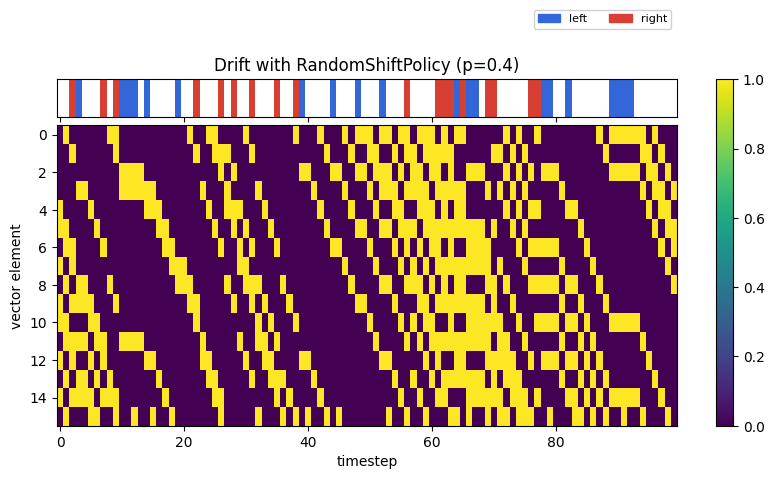

action counts: {'none': 62, 'left': 20, 'right': 18}


In [3]:
task = DriftTask(vector_length=16, prob=0.3)
obs, acts = rollout(task, RandomShiftPolicy(action_probability=0.4), num_steps=100, seed=0)
plot_rollout(obs, acts, 'Drift with RandomShiftPolicy (p=0.4)')

### No actions vs. a shift-heavy policy

Same task, `p=0` (pure drift) vs `p=0.8` (mostly shifting).

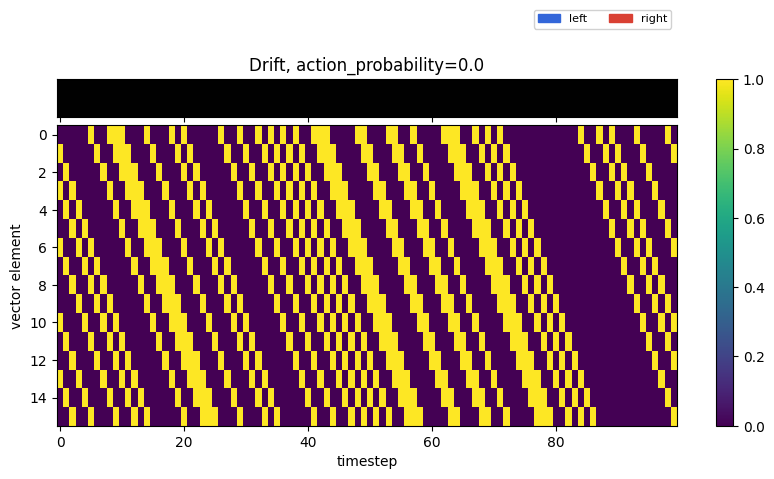

action counts: {'none': 100, 'left': 0, 'right': 0}


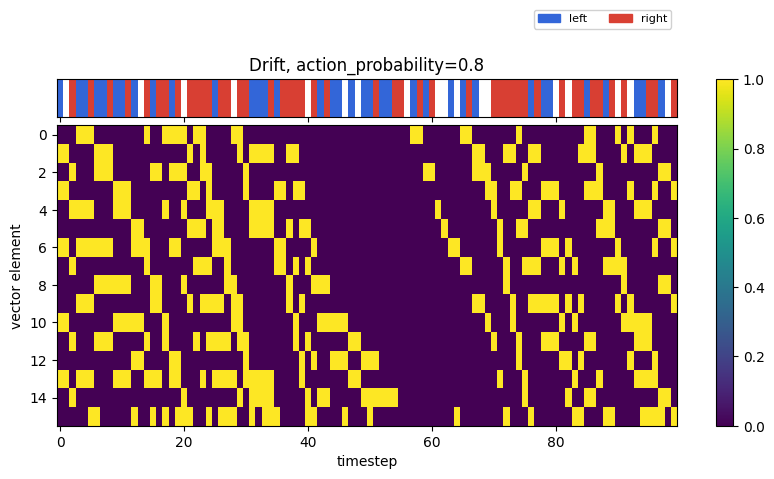

action counts: {'none': 18, 'left': 36, 'right': 46}


In [4]:
for p in [0.0, 0.8]:
    task = DriftTask(vector_length=16, prob=0.3)
    obs, acts = rollout(task, RandomShiftPolicy(action_probability=p), num_steps=100, seed=1)
    plot_rollout(obs, acts, f'Drift, action_probability={p}')

## 2. Binary noise + actions

With `resample_prob=1` the field is redrawn every step, so a shift only reshuffles
one already-random column -- the action has little visible effect. With a low
`resample_prob` the field is "sticky", so shifts visibly translate the pattern.


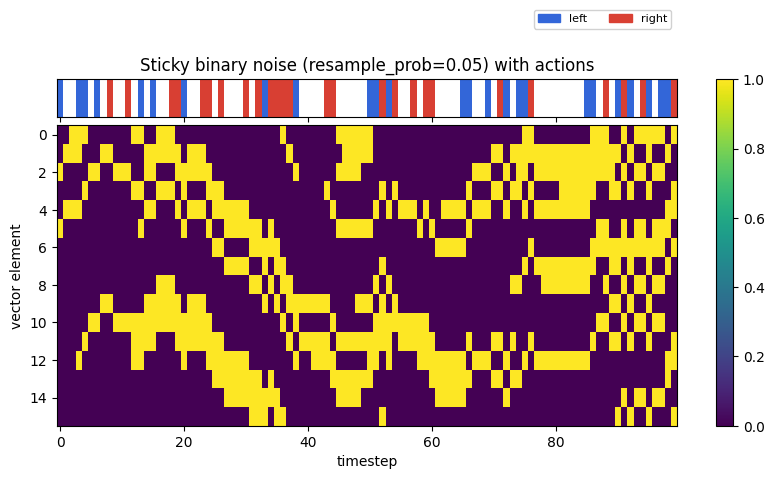

action counts: {'none': 49, 'left': 25, 'right': 26}


In [5]:
task = BinaryNoiseTask(vector_length=16, prob=0.3, resample_prob=0.05)
obs, acts = rollout(task, RandomShiftPolicy(action_probability=0.5), num_steps=100, seed=2)
plot_rollout(obs, acts, 'Sticky binary noise (resample_prob=0.05) with actions')

## 3. Gaussian process + actions

The GP field is resampled from its temporal history each step, so an action
shifts the current observation but does not persist into the latent history
(see the note in `GaussianProcessTask`).


/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: divide by zero encountered in matmul
  mean = weights @ self._history
/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: overflow encountered in matmul
  mean = weights @ self._history
/Users/nicholaswatters/Desktop/grad_school/research/exploration_policies/toy_v1/tasks/../tasks/gaussian_process.py:81: RuntimeWarning: invalid value encountered in matmul
  mean = weights @ self._history


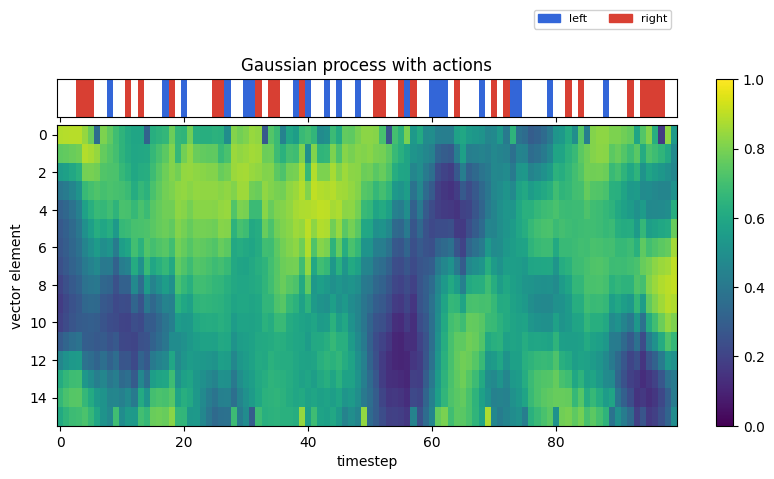

action counts: {'none': 54, 'left': 20, 'right': 26}


In [6]:
task = GaussianProcessTask(vector_length=16, spatial_temperature=3.0, temporal_temperature=5.0)
obs, acts = rollout(task, RandomShiftPolicy(action_probability=0.5), num_steps=100, seed=3)
plot_rollout(obs, acts, 'Gaussian process with actions')

## Action feedback

The optional feedback appends the one-hot of the action *just executed* to the
input vector on the following step (`feedback(actions)[t] = one_hot(action[t-1])`,
zeros at t=0). The models use this optionally; here is what it looks like.


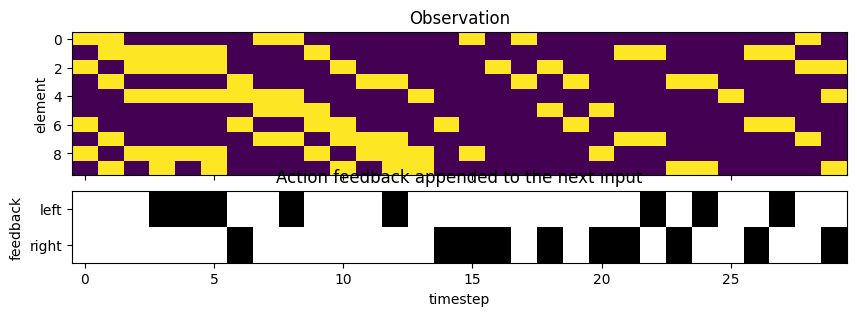

In [7]:
from tasks.actions import feedback, one_hot

task = DriftTask(vector_length=10, prob=0.3)
obs, acts = rollout(task, RandomShiftPolicy(action_probability=0.6), num_steps=30, seed=4)
fb = feedback(acts)   # (T, 2)

fig, axes = plt.subplots(2, 1, figsize=(10, 3), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.15})
im0 = axes[0].imshow(obs.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_ylabel('element'); axes[0].set_title('Observation')
im1 = axes[1].imshow(fb.T, aspect='auto', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['left', 'right'])
axes[1].set_ylabel('feedback'); axes[1].set_xlabel('timestep')
axes[1].set_title('Action feedback appended to the next input')
plt.show()